## Rol: Hyperparameter Tuner (PB-13)

### Objetivo
Optimizar hiperparámetros de los candidatos seleccionados en Sprint 3 y justificar **qué estrategia de búsqueda conviene para cada modelo**.

### Decisiones de este template
- **Métrica principal** por defecto: `precision`
- **Top 3 por defecto**: `rf`, `dt`, `knn`
- **No todos los modelos usan Grid, Random y Optuna a la vez**
- La estrategia se define **por modelo**
- **No usa el test set final**

### Criterio metodológico por defecto
- **RF**: `grid` + `random` + `optuna`
- **DT**: `grid` + `random`
- **KNN**: `grid`

### Outputs esperados
- `models/tuning_results.csv`
- `models/tuning_best_search_per_model.csv`
- `models/tuning_baseline_vs_tuned.csv`
- `reports/figures/sprint4/tuning_search_strategy_comparison.png`
- `models/tuned_<model>_<search_method>.pkl`

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    optuna = None
    OPTUNA_AVAILABLE = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Optuna available:", OPTUNA_AVAILABLE)

Optuna available: False


In [2]:
PROJECT_ROOT = Path(".").resolve().parent if Path.cwd().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "figures" / "sprint4"

TARGET_COL = "IsBadBuy"
PRIMARY_SCORING = "precision"

USE_SPRINT3_SELECTION_FILE = True
DEFAULT_TOP_CANDIDATES = ["rf", "dt", "knn"]
TOP_K = 3

MODEL_SELECTION_PATH = MODELS_DIR / "model_selection_candidates.csv"
BASELINE_COMPARISON_PATH = MODELS_DIR / "model_comparison_summary.csv"
BASELINE_EVAL_PATH = MODELS_DIR / "evaluation_cv_summary.csv"

TRAIN_GENERAL_PATH = DATA_DIR / "train_balanced.csv"
TRAIN_KNN_PATH = DATA_DIR / "train_balanced_knn_raw.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
if USE_SPRINT3_SELECTION_FILE and MODEL_SELECTION_PATH.exists():
    selected_df = pd.read_csv(MODEL_SELECTION_PATH)
    active_candidates = selected_df["model_key"].dropna().astype(str).tolist() if "model_key" in selected_df.columns else DEFAULT_TOP_CANDIDATES.copy()
else:
    active_candidates = DEFAULT_TOP_CANDIDATES.copy()

active_candidates = active_candidates[:TOP_K] if TOP_K is not None else active_candidates
print("Candidatos activos:", active_candidates)

Candidatos activos: ['rf', 'dt', 'knn']


In [4]:
MODEL_CONFIG = {
    "rf": {
        "artifact_path": MODELS_DIR / "baseline_rf.pkl",
        "data_variant": "general",
        "search_methods": ["grid"],  # solo grid
        "rationale": "RF se deja con un grid mínimo para cumplir con probar más de un hiperparámetro sin bloquear la laptop.",
        "grid": {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [10, None],
        },
        "n_iter_random": 4,
    },

    "dt": {
        "artifact_path": MODELS_DIR / "baseline_dt.pkl",
        "data_variant": "general",
        "search_methods": ["grid"],  # solo grid
        "rationale": "DT usa un grid mínimo y rápido.",
        "grid": {
            "clf__max_depth": [5, None],
            "clf__criterion": ["gini", "entropy"],
        },
        "n_iter_random": 4,
    },

    "knn": {
        "artifact_path": MODELS_DIR / "baseline_knn.pkl",
        "data_variant": "knn_raw",
        "search_methods": ["grid"],  # solo grid
        "rationale": "KNN mantiene grid exhaustivo en un espacio muy pequeño.",
        "grid": {
            "clf__n_neighbors": [5, 11],
            "clf__weights": ["uniform", "distance"],
        },
        "n_iter_random": 4,
    },

    "lr": {
        "artifact_path": MODELS_DIR / "baseline_lr.pkl",
        "data_variant": "general",
        "search_methods": ["grid"],
        "rationale": "LR con grid mínimo.",
        "grid": {
            "clf__C": [0.1, 1],
            "clf__penalty": ["l2"],
        },
    },

    "gb": {
        "artifact_path": MODELS_DIR / "baseline_gb.pkl",
        "data_variant": "general",
        "search_methods": ["random"],  # si luego vuelves a gb
        "rationale": "GB se deja fuera por ahora o con random pequeño si entra después.",
        "grid": {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.05, 0.1],
        },
        "random": {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.03, 0.05, 0.1],
            "clf__max_depth": [2, 3],
        },
        "n_iter_random": 4,
    },
}

benchmark_models = [m for m in active_candidates if m in MODEL_CONFIG]
benchmark_plan_df = pd.DataFrame([
    {
        "model_key": m,
        "data_variant": MODEL_CONFIG[m]["data_variant"],
        "search_methods": ", ".join(MODEL_CONFIG[m]["search_methods"]),
        "rationale": MODEL_CONFIG[m]["rationale"],
    }
    for m in benchmark_models
])
display(benchmark_plan_df)

,model_key,data_variant,search_methods,rationale
0,rf,general,grid,RF se deja con un grid mínimo para cumplir con...
1,dt,general,grid,DT usa un grid mínimo y rápido.
2,knn,knn_raw,grid,KNN mantiene grid exhaustivo en un espacio muy...


In [5]:
train_general_df = pd.read_csv(TRAIN_GENERAL_PATH)
train_knn_df = pd.read_csv(TRAIN_KNN_PATH) if TRAIN_KNN_PATH.exists() else train_general_df.copy()

datasets = {"general": train_general_df, "knn_raw": train_knn_df}

def get_xy(data_variant: str):
    df = datasets[data_variant].copy()
    X = df.drop(columns=[TARGET_COL]).copy()
    y = df[TARGET_COL].copy()
    return X, y

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
def run_grid_search(pipe, param_grid, X, y, cv, scoring="precision"):
    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        return_train_score=False,
    )
    start = time.time()
    search.fit(X, y)
    elapsed = time.time() - start
    return search, elapsed

def run_random_search(pipe, param_dist, X, y, cv, scoring="precision", n_iter=20, random_state=42):
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        random_state=random_state,
        return_train_score=False,
    )
    start = time.time()
    search.fit(X, y)
    elapsed = time.time() - start
    return search, elapsed

In [7]:
def suggest_optuna_params(trial, model_key):
    if model_key == "rf":
        return {
            "clf__n_estimators": trial.suggest_int("clf__n_estimators", 100, 700, step=100),
            "clf__max_depth": trial.suggest_categorical("clf__max_depth", [5, 10, 15, 20, None]),
            "clf__min_samples_split": trial.suggest_int("clf__min_samples_split", 2, 15),
            "clf__min_samples_leaf": trial.suggest_int("clf__min_samples_leaf", 1, 6),
            "clf__max_features": trial.suggest_categorical("clf__max_features", ["sqrt", "log2", None]),
        }
    elif model_key == "dt":
        return {
            "clf__max_depth": trial.suggest_categorical("clf__max_depth", [3, 5, 10, 15, 20, None]),
            "clf__min_samples_split": trial.suggest_int("clf__min_samples_split", 2, 15),
            "clf__min_samples_leaf": trial.suggest_int("clf__min_samples_leaf", 1, 6),
            "clf__criterion": trial.suggest_categorical("clf__criterion", ["gini", "entropy", "log_loss"]),
        }
    elif model_key == "knn":
        return {
            "clf__n_neighbors": trial.suggest_int("clf__n_neighbors", 3, 25, step=2),
            "clf__weights": trial.suggest_categorical("clf__weights", ["uniform", "distance"]),
            "clf__p": trial.suggest_categorical("clf__p", [1, 2]),
        }
    elif model_key == "gb":
        return {
            "clf__n_estimators": trial.suggest_int("clf__n_estimators", 100, 500, step=50),
            "clf__learning_rate": trial.suggest_float("clf__learning_rate", 0.01, 0.2, log=True),
            "clf__max_depth": trial.suggest_int("clf__max_depth", 2, 5),
            "clf__subsample": trial.suggest_float("clf__subsample", 0.7, 1.0),
            "clf__min_samples_split": trial.suggest_int("clf__min_samples_split", 2, 10),
        }
    else:
        raise ValueError(f"Optuna no configurado para {model_key}")

def run_optuna_search(pipe, model_key, X, y, cv, scoring="precision", n_trials=10, random_state=42):
    if not OPTUNA_AVAILABLE:
        raise ImportError("Optuna no está instalado.")

    def objective(trial):
        params = suggest_optuna_params(trial, model_key)
        candidate = clone(pipe)
        candidate.set_params(**params)
        scores = cross_val_score(candidate, X, y, cv=cv, scoring=scoring, n_jobs=1)
        return float(np.mean(scores))

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    start = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    elapsed = time.time() - start

    best_pipe = clone(pipe)
    best_pipe.set_params(**study.best_params)
    best_pipe.fit(X, y)
    return study, best_pipe, elapsed

In [8]:
benchmark_rows = []

for model_key in benchmark_models:
    cfg = MODEL_CONFIG[model_key]
    artifact_path = cfg["artifact_path"]

    if not artifact_path.exists():
        print(f"Skipping {model_key}: no existe {artifact_path}")
        continue

    X_train, y_train = get_xy(cfg["data_variant"])
    base_pipe = joblib.load(artifact_path)

    print("\n" + "=" * 40)
    print(f"Model: {model_key}")
    print(f"Search methods: {cfg['search_methods']}")
    print("=" * 40)

    for method in cfg["search_methods"]:
        if method == "grid":
            search, elapsed = run_grid_search(
                pipe=clone(base_pipe),
                param_grid=cfg["grid"],
                X=X_train,
                y=y_train,
                cv=cv,
                scoring=PRIMARY_SCORING,
            )
            tuned_path = MODELS_DIR / f"tuned_{model_key}_grid.pkl"
            joblib.dump(search.best_estimator_, tuned_path)

            benchmark_rows.append({
                "model_key": model_key,
                "search_method": "grid",
                "primary_metric": PRIMARY_SCORING,
                "best_cv_score": search.best_score_,
                "best_params": json.dumps(search.best_params_),
                "fit_time_seconds": round(elapsed, 1),
                "artifact_path": str(tuned_path),
                "data_variant": cfg["data_variant"],
                "rationale": cfg["rationale"],
            })

        elif method == "random":
            search, elapsed = run_random_search(
                pipe=clone(base_pipe),
                param_dist=cfg["random"],
                X=X_train,
                y=y_train,
                cv=cv,
                scoring=PRIMARY_SCORING,
                n_iter=cfg.get("n_iter_random", 20),
                random_state=42,
            )
            tuned_path = MODELS_DIR / f"tuned_{model_key}_random.pkl"
            joblib.dump(search.best_estimator_, tuned_path)

            benchmark_rows.append({
                "model_key": model_key,
                "search_method": "random",
                "primary_metric": PRIMARY_SCORING,
                "best_cv_score": search.best_score_,
                "best_params": json.dumps(search.best_params_),
                "fit_time_seconds": round(elapsed, 1),
                "artifact_path": str(tuned_path),
                "data_variant": cfg["data_variant"],
                "rationale": cfg["rationale"],
            })

        elif method == "optuna":
            if not OPTUNA_AVAILABLE:
                print(f"Skipping optuna for {model_key}: Optuna no disponible.")
                continue
            study, best_pipe, elapsed = run_optuna_search(
                pipe=clone(base_pipe),
                model_key=model_key,
                X=X_train,
                y=y_train,
                cv=cv,
                scoring=PRIMARY_SCORING,
                n_trials=25,
                random_state=42,
            )
            tuned_path = MODELS_DIR / f"tuned_{model_key}_optuna.pkl"
            joblib.dump(best_pipe, tuned_path)

            benchmark_rows.append({
                "model_key": model_key,
                "search_method": "optuna",
                "primary_metric": PRIMARY_SCORING,
                "best_cv_score": study.best_value,
                "best_params": json.dumps(study.best_params),
                "fit_time_seconds": round(elapsed, 1),
                "artifact_path": str(tuned_path),
                "data_variant": cfg["data_variant"],
                "rationale": cfg["rationale"],
            })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    by=["model_key", "best_cv_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(benchmark_df)


Model: rf
Search methods: ['grid']
Fitting 5 folds for each of 4 candidates, totalling 20 fits


KeyboardInterrupt: 

In [11]:
tuning_results = pd.read_csv(PROJECT_ROOT / "models" / "tuning_results.csv")
display(tuning_results)
print(tuning_results[["model_key", "search_method", "best_cv_score", "artifact_path"]])

,model_key,search_method,primary_metric,best_cv_score,best_params,fit_time_seconds,artifact_path,data_variant,rationale
0,dt,grid,precision,0.878095,"{""clf__criterion"": ""entropy"", ""clf__max_depth""...",144.4,/Users/alexandralozano/dp261-g1/models/tuned_d...,general,DT usa un grid mínimo y rápido.
1,knn,grid,precision,0.762834,"{""clf__n_neighbors"": 5, ""clf__weights"": ""dista...",2356.8,/Users/alexandralozano/dp261-g1/models/tuned_k...,knn_raw,KNN mantiene grid exhaustivo en un espacio muy...
2,rf,grid,precision,0.981168,"{""clf__max_depth"": null, ""clf__n_estimators"": ...",3351.7,/Users/alexandralozano/dp261-g1/models/tuned_r...,general,RF se deja con un grid mínimo para cumplir con...


  model_key search_method  best_cv_score                                      artifact_path
0        dt          grid       0.878095  /Users/alexandralozano/dp261-g1/models/tuned_d...
1       knn          grid       0.762834  /Users/alexandralozano/dp261-g1/models/tuned_k...
2        rf          grid       0.981168  /Users/alexandralozano/dp261-g1/models/tuned_r...


In [13]:
tuning_results_df = pd.read_csv(PROJECT_ROOT / "models" / "tuning_results.csv")

best_search_per_model_df = (
    tuning_results_df.sort_values(
        by=["model_key", "best_cv_score"],
        ascending=[True, False]
    )
    .groupby("model_key", as_index=False)
    .first()
)

display(best_search_per_model_df)

BEST_SEARCH_PATH = PROJECT_ROOT / "models" / "tuning_best_search_per_model.csv"
best_search_per_model_df.to_csv(BEST_SEARCH_PATH, index=False)
print("Saved:", BEST_SEARCH_PATH)

,model_key,search_method,primary_metric,best_cv_score,best_params,fit_time_seconds,artifact_path,data_variant,rationale
0,dt,grid,precision,0.878095,"{""clf__criterion"": ""entropy"", ""clf__max_depth""...",144.4,/Users/alexandralozano/dp261-g1/models/tuned_d...,general,DT usa un grid mínimo y rápido.
1,knn,grid,precision,0.762834,"{""clf__n_neighbors"": 5, ""clf__weights"": ""dista...",2356.8,/Users/alexandralozano/dp261-g1/models/tuned_k...,knn_raw,KNN mantiene grid exhaustivo en un espacio muy...
2,rf,grid,precision,0.981168,"{""clf__max_depth"": null, ""clf__n_estimators"": ...",3351.7,/Users/alexandralozano/dp261-g1/models/tuned_r...,general,RF se deja con un grid mínimo para cumplir con...


Saved: /Users/alexandralozano/dp261-g1/models/tuning_best_search_per_model.csv


In [14]:
if (PROJECT_ROOT / "models" / "model_comparison_summary.csv").exists():
    baseline_df = pd.read_csv(PROJECT_ROOT / "models" / "model_comparison_summary.csv")
elif (PROJECT_ROOT / "models" / "evaluation_cv_summary.csv").exists():
    baseline_df = pd.read_csv(PROJECT_ROOT / "models" / "evaluation_cv_summary.csv")
else:
    baseline_df = pd.DataFrame()

if not baseline_df.empty:
    baseline_vs_best_df = baseline_df.merge(
        best_search_per_model_df[["model_key", "search_method", "best_cv_score"]],
        on="model_key",
        how="inner",
    )
    baseline_vs_best_df["improvement_abs"] = (
        baseline_vs_best_df["best_cv_score"] - baseline_vs_best_df["test_precision_mean"]
    )
    baseline_vs_best_df["improvement_pct"] = np.where(
        baseline_vs_best_df["test_precision_mean"] != 0,
        baseline_vs_best_df["improvement_abs"] / baseline_vs_best_df["test_precision_mean"] * 100,
        np.nan,
    )
else:
    baseline_vs_best_df = pd.DataFrame()

display(baseline_vs_best_df)

,rank,model_key,primary_metric,cv_folds,test_accuracy_mean,test_accuracy_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,test_f1_mean,test_f1_std,test_roc_auc_mean,test_roc_auc_std,fit_time_mean,score_time_mean,score_method,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,train_accuracy_mean,accuracy_gap,train_precision_mean,precision_gap,train_recall_mean,recall_gap,train_f1_mean,f1_gap,train_roc_auc_mean,roc_auc_gap,f1_diagnosis,rank_primary_metric,interpretability,model_family,speed_bucket,precision_recall_gap,selected_for_sprint4,selection_reason,discard_reason,search_method,best_cv_score,improvement_abs,improvement_pct
0,1,rf,precision,5,0.988653,0.000424,0.979625,0.000929,0.998067,0.000272,0.988759,0.000414,0.999437,0.000143,83.685216,2.240954,predict_proba,0.988653,0.979624,0.998067,0.988759,0.999437,0.999592,1.0,0.011347,1.0,0.020375,1.0,0.001933,1.0,0.011241,1.0,0.000563,sin brecha fuerte,1,media,ensamble de árboles,más lento,-0.018442,True,Top 1 por Precision (CV) | prioriza control de...,NaN,grid,0.981168,0.001543,0.157508
1,2,dt,precision,5,0.925134,0.001772,0.870759,0.002643,0.998477,0.000132,0.930252,0.001539,0.925134,0.001772,13.764367,0.434326,predict_proba,0.925134,0.870751,0.998477,0.930250,0.925134,0.870186,1.0,0.074866,1.0,0.129241,1.0,0.001523,1.0,0.069748,1.0,0.074866,brecha moderada,2,alta,árbol simple,más rápido,-0.127718,True,Top 2 por Precision (CV) | prioriza control de...,NaN,grid,0.878095,0.007337,0.842565
2,3,knn,precision,5,0.824763,0.000943,0.754409,0.001681,0.963050,0.002012,0.846053,0.000603,0.907731,0.000906,1.142385,333.830546,predict_proba,0.824763,0.754402,0.963050,0.846052,0.907722,0.856151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,media-baja,instancias / distancia,más rápido,-0.208642,True,Top 3 por Precision (CV) | prioriza control de...,NaN,grid,0.762834,0.008426,1.116845


In [15]:
BENCHMARK_RESULTS_PATH = PROJECT_ROOT / "models" / "tuning_results.csv"
BEST_SEARCH_PATH = PROJECT_ROOT / "models" / "tuning_best_search_per_model.csv"
BASELINE_VS_TUNED_PATH = PROJECT_ROOT / "models" / "tuning_baseline_vs_tuned.csv"

tuning_results_df.to_csv(BENCHMARK_RESULTS_PATH, index=False)
best_search_per_model_df.to_csv(BEST_SEARCH_PATH, index=False)

if not baseline_vs_best_df.empty:
    baseline_vs_best_df.to_csv(BASELINE_VS_TUNED_PATH, index=False)

print("Saved:", BENCHMARK_RESULTS_PATH)
print("Saved:", BEST_SEARCH_PATH)
print("Saved:", BASELINE_VS_TUNED_PATH if not baseline_vs_best_df.empty else "baseline comparison skipped")

Saved: /Users/alexandralozano/dp261-g1/models/tuning_results.csv
Saved: /Users/alexandralozano/dp261-g1/models/tuning_best_search_per_model.csv
Saved: /Users/alexandralozano/dp261-g1/models/tuning_baseline_vs_tuned.csv


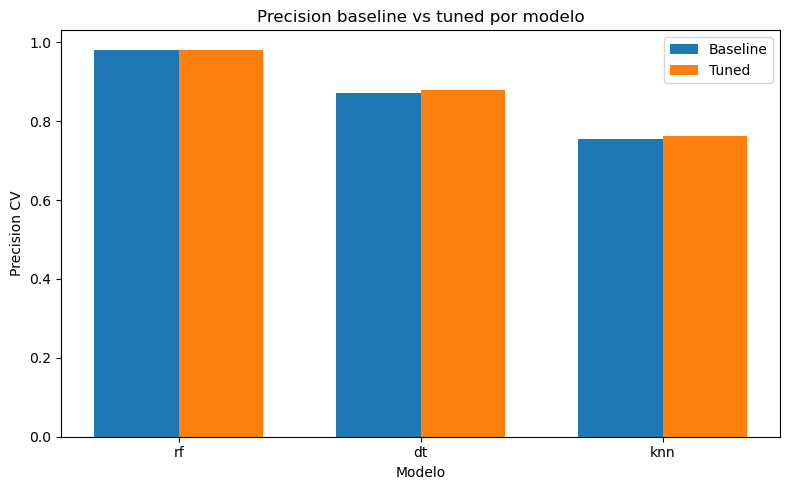

Saved: /Users/alexandralozano/dp261-g1/reports/figures/sprint4/tuning_baseline_vs_tuned_precision.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = baseline_vs_best_df.copy()

x = np.arange(len(plot_df))
width = 0.35

ax.bar(x - width/2, plot_df["test_precision_mean"], width, label="Baseline")
ax.bar(x + width/2, plot_df["best_cv_score"], width, label="Tuned")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_key"])
ax.set_title("Precision baseline vs tuned por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Precision CV")
ax.legend()

plt.tight_layout()

baseline_vs_tuned_fig_path = PROJECT_ROOT / "reports" / "figures" / "sprint4" / "tuning_baseline_vs_tuned_precision.png"
plt.savefig(baseline_vs_tuned_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", baseline_vs_tuned_fig_path)